In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

In [2]:
X, y_true = make_moons(n_samples=300, noise=0.08, random_state=42)

In [3]:
X.shape

(300, 2)

In [4]:
X[:5]

array([[ 0.65880058, -0.35596254],
       [ 1.98630199, -0.13348998],
       [-0.11162344,  0.4550811 ],
       [ 0.90500816,  0.26679823],
       [ 1.18161893, -0.49496507]])

In [5]:
y_true[:5]

array([1, 1, 1, 0, 1])

In [6]:
import matplotlib.pyplot as plt

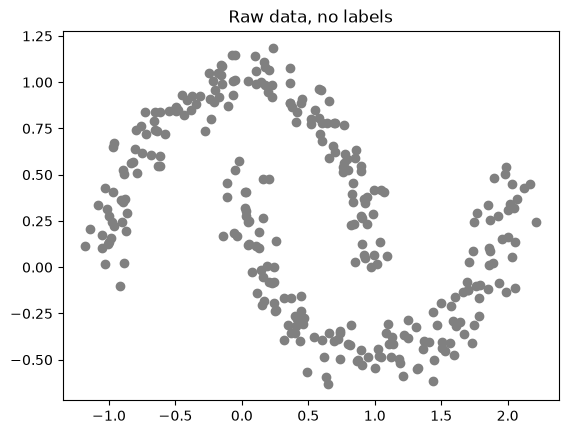

In [7]:
plt.scatter(X[:, 0], X[:, 1], c='gray')
plt.title('Raw data, no labels')
plt.show()

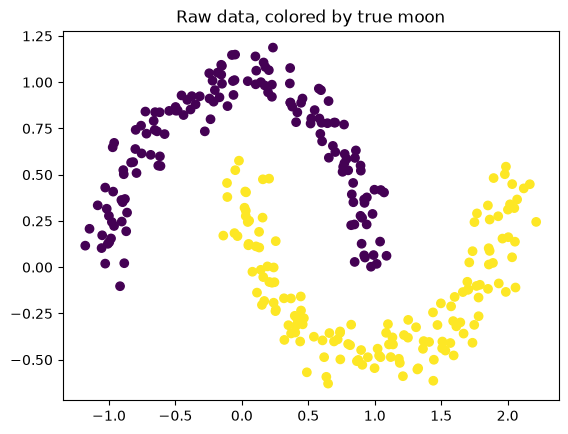

In [8]:
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis')
plt.title('Raw data, colored by true moon')
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
X_scaled[:5]

array([[ 0.18122939, -1.22454431],
       [ 1.70255099, -0.77872801],
       [-0.70167944,  0.40071894],
       [ 0.4633842 ,  0.02341591],
       [ 0.78038117, -1.50309369]])

In [12]:
from sklearn.cluster import KMeans

In [13]:
inertias = []
k_range = range(1, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

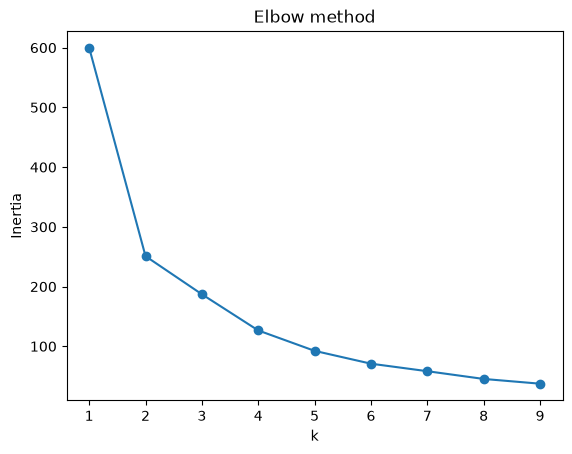

In [14]:
plt.plot(k_range, inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow method')
plt.show()

In [15]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

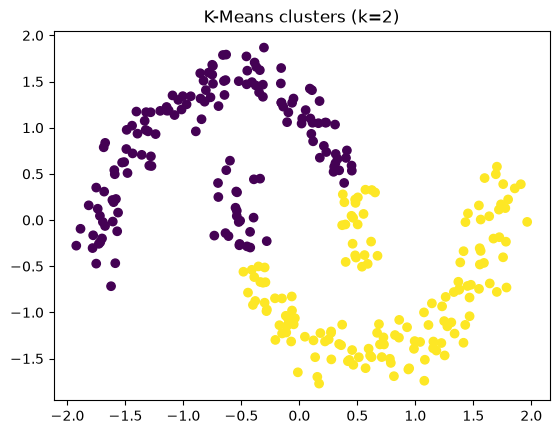

In [16]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, cmap='viridis')
plt.title('K-Means clusters (k=2)')
plt.show()

In [17]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [18]:
linked = linkage(X_scaled, method='single')

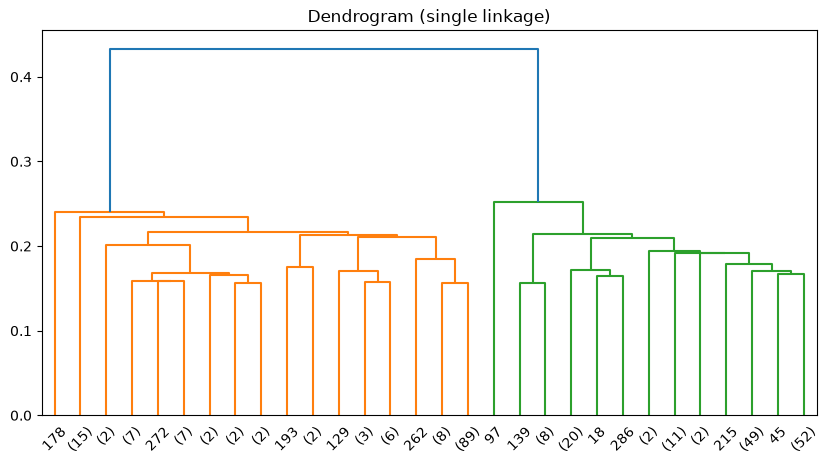

In [19]:
plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.title('Dendrogram (single linkage)')
plt.show()

In [20]:
hierarchical = AgglomerativeClustering(n_clusters=2, linkage='single')
hierarchical_labels = hierarchical.fit_predict(X_scaled)

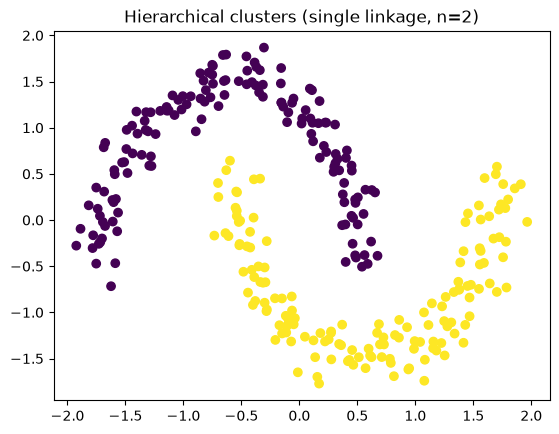

In [21]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=hierarchical_labels, cmap='viridis')
plt.title('Hierarchical clusters (single linkage, n=2)')
plt.show()

In [22]:
hierarchical_avg = AgglomerativeClustering(n_clusters=2, linkage='average')
hierarchical_avg_labels = hierarchical_avg.fit_predict(X_scaled)

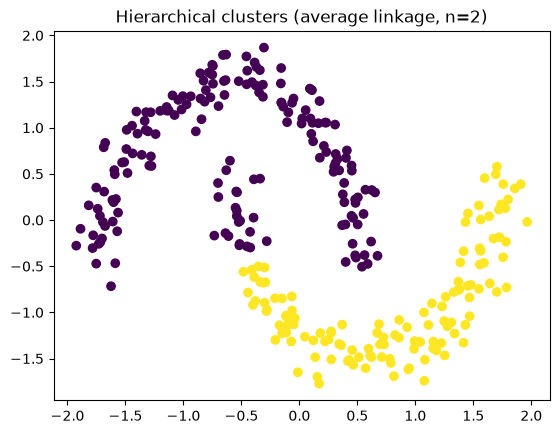

In [23]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=hierarchical_avg_labels, cmap='viridis')
plt.title('Hierarchical clusters (average linkage, n=2)')
plt.show()

In [24]:
from sklearn.cluster import DBSCAN

In [25]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

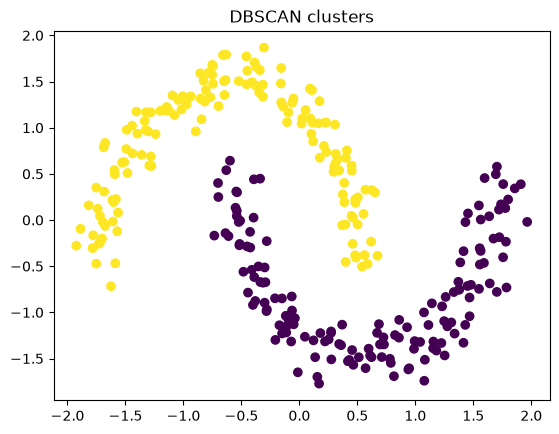

In [26]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan_labels, cmap='viridis')
plt.title('DBSCAN clusters')
plt.show()

In [27]:
np.unique(dbscan_labels)

array([0, 1])

In [28]:
dbscan_tight = DBSCAN(eps=0.15, min_samples=5)
dbscan_tight_labels = dbscan_tight.fit_predict(X_scaled)

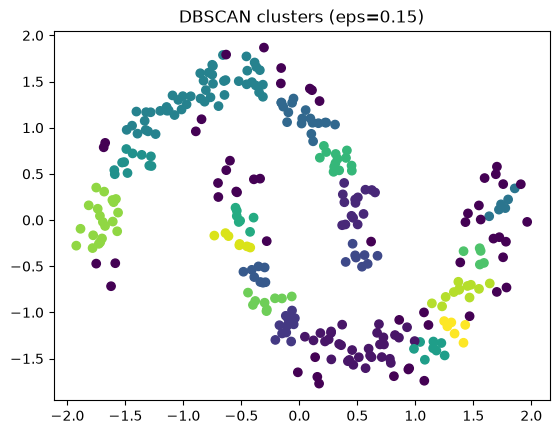

In [29]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan_tight_labels, cmap='viridis')
plt.title('DBSCAN clusters (eps=0.15)')
plt.show()

In [30]:
np.unique(dbscan_tight_labels)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17])

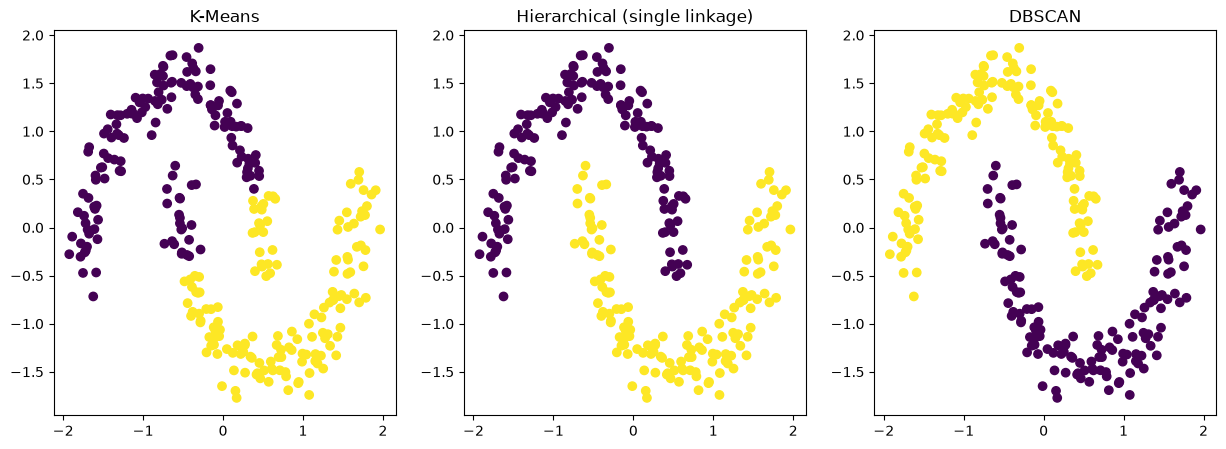

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, cmap='viridis')
axes[0].set_title('K-Means')

axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=hierarchical_labels, cmap='viridis')
axes[1].set_title('Hierarchical (single linkage)')

axes[2].scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan_labels, cmap='viridis')
axes[2].set_title('DBSCAN')

plt.show()

In [32]:
from sklearn.metrics import adjusted_rand_score, silhouette_score

In [33]:
ari_kmeans = adjusted_rand_score(y_true, kmeans_labels)
ari_hierarchical = adjusted_rand_score(y_true, hierarchical_labels)
ari_dbscan = adjusted_rand_score(y_true, dbscan_labels)

In [34]:
print(ari_kmeans)
print(ari_hierarchical)
print(ari_dbscan)

0.47896853094705444
1.0
1.0


In [35]:
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
sil_hierarchical = silhouette_score(X_scaled, hierarchical_labels)
sil_dbscan = silhouette_score(X_scaled, dbscan_labels)

In [36]:
print(sil_kmeans)
print(sil_hierarchical)
print(sil_dbscan)

0.49363038566825634
0.38025084295785
0.38025084295785


In [37]:
import joblib

In [38]:
joblib.dump(dbscan, 'dbscan_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']